# Background

## Relevant papers
 * [Radar Echoes From the Moon](https://web.archive.org/web/20081029000712/http://www.eagle.ca/~harry/ba/eme/index.htm) -- historical
 * [Planetary Radar - State-of-the-Art Review](https://www.mdpi.com/2072-4292/15/23/5605) -- 2023 overview
 * [Planetary Radar Astronomy](https://nap.nationalacademies.org/read/21729/chapter/8) -- 2015 overview
 * [Planetary Radar](https://echo.jpl.nasa.gov/asteroids/ostro_1998_encyc_ss.pdf) -- 1998 overview
 * [Planetary Delay-Doppler Radar and the Long-Code Method](https://echo.jpl.nasa.gov/asteroids/harmon.2002.long.code.pdf) -- long-code method (recommends intercode -- coherent code sequence) for underspread Moon
 * [Earth-Based Radar Observations of Venus -- PDS Archive Description](https://pds-geosciences.wustl.edu/venus/arcb_nrao-v-rtls_gbt-3-delaydoppler-v1/vrm_90xx/document/venus_radar.pdf) -- Arecibo Venus data description

To build a radar map of the moon, we want to process all of the available data (many "Looks" across many days) into intensity values for each point on the moon's surface.

In essence, we combine samples over a duration of a few minutes into a coherent doppler/delay (DD) Look, which we then map to intensity values the moon's surface. We can repeat this process for each Look, and then incoherently combine the Looks by taking the average of the intensity values at each point (or some other statistic).

There are several relevant frames:
* The RX frame (at Stockert)
* The TX frame (at Dwingeloo)
* The Moon frame, which is where the bounces occur.
 - The Moon is significantly oblate, which requires raycasting to model accurately!

Bouncing a radar signal from the transmitter to the moon to the receiver causes a Doppler effect, which is usually though of as a change in frequency or pitch. This effect can be interpreted in the frequency domain, or the time domain:
* Frequency Domain: at each tx or rx sample time, there is an instantaneous frequency shift caused by the relative velocity of the two bodies during the signal round trip -- this is the classical Doppler shift.
* Time Domain: at each rx sample time, there is a corrected tx sample timing caused by the signal propagation delay. The effect of shifting the signal timing is to cause an apparent frequency shift!

Generally, the Time Domain view is more correct. It reflects the actual physics better: different frequencies within the signal are actually *scaled* (proportionate to the frequency), not shifted.

A small complication is that the tx files modulate the carrier frequency (approximate 1.3 GHz) before RF transmission, and the received RF signal is demodulated from the same carrier frequency (and down-sampled) to create the rx files.

This means that we use a combination of these approaches
1. First, we shift the signal by the (time-varying) doppler at the carrier frequency
2. Then, we resample the signal according to the (time-varying) timing

A. (1) isn't quite correct 
  i. As mentioned before, the shift should be proportional to the frequency, and our modulated tx signal has a bandwidth!
  ii.  Also, each point on the moon will actually have its own doppler.
B. (2) is tricky for a large surface (like the moon)
  i. Different surface points will actually have different timings

Do any of these concerns matter?
Ai. MAYBE: a typical dlt is 1.3e-6 and with 1000 doppler bins the change in dlt is 2e-12.
At our 1.3 GHz carrier frequency fc, the doppler bins vary by 0.002 Hz.
Our Zadoff Chu signal has a bandwidth fzc of 50 kHz (there is some variation between the experiments).
At our carrier frequency fc, this means that the change in doppler would be ~0.02 Hz over the fzc bandwidth, or 100 bins!
BUT: resampling (B) does also adjust the frequency a little, in the proper scaling way...
(Can it really be this significant? Could we test by bandpassing the tx signal to be more narrowband?)
(Or I could synthesize a (short) RF sequence, and look at the difference!
--> Based on simulation experiments, de-sampling then de-shifting of the demodulated signal is equivalent to the theoretical ideal processing pipeline (de-sampling *then* demodulating).

Aii.

Bi.


We can apply these corrections to either the TX samples or the RX samples (or one to each). We think it's better to apply them to the TX:
- in the case of resampling, because we know what the theoretical ZC sequence should look like, so we can apply this knowledge to do 'perfect' interpolation.
- in the case of compensating, the preference is more subjective but we think that the strong and clean TX signal will handle the numerical operations better.

NOTE: Numerical precision is a pretty significant factor in these calculations, due to the very small time variations.

Because of light time delays, and the changing relative motion of the Earth and Moon, and oblateness of the Moon, we need to use raycasting to model the doppler and delay.

The most tricky part is assembling the Looks. We have several options to convert the samples into moon surface values.
1. Full raycast: for each rx sample of the Look, cast a BACK ray to each point on the moon and then a BACK ray to the TX. Correct the TX sample timing accordingly and correlate the corrected signal over the duration of the Look with the RX signal to get the moon surface intensity at that point. This takes into account the full complexity of the light propagation and relative motion of the 3 points of interest (tx, bounce, rx).
    1. NOTE: this is likely very computationally intensive!
2. Sub-radar point SRP) raycast. The change in relative motion (and thus doppler) due to the delay depth of the moon is probably pretty small. So we can instead just use the SRP (rather than each point on the moon) to estimate the Doppler correction.
    1. Then correct the {RX or TX TBD} samples:
        1. Time domain: Resample the TX or RX signal to the adjusted timestamps
        2. Frequency domain: Shift the {RX, TX} signal frequency by the time-varying doppler
    2. Correlate the corrected signal with the (original) {OTHER} signal across a range of doppler shifts (due to the motion of the limbs of the moon): this yields a single "look" at the rx signal start time
    3. Then raycast for points on the lunar surface to predict the dopplers/delays of at the "look" time for each point, and convert the "look" doppler/delay intensity values into moon coordinates.
3. Sub-radar, linear rate of Doppler. Like 2, but instead of computing the corrected sample timing or instantaneous frequency shift for each sample, just compute them for the {RX, TX} start and end times and assume a linear rate in between. Use this simpler correction for (2.A), then do (2.B) and (2.C) as in (2).
    1. NOTE: this is what we've been doing (frequency domain only)

For each raycast, we have several light-time correction approaches (from SPICE):
- LT -- correct for the one-way light-time using a Newtonian formulation
- LT+S -- LN plus a correction for stellar aberration
- CN -- Converged Newtonian (multiple iterations until the solution converges)
- CN+S -- CN plus stellar aberration

We think LT is good enough (and much faster), and the "+S" isn't needed because we just need the light time and range rates (not the direction).

# Imports and configuration

In [1]:
# Install dependencies
#! pip install --quiet --upgrade astropy astroquery cspyce cupy-cuda12x healpy ipympl jplephem matplotlib numpy scipy sigmf tqdm

In [2]:
import os
import pickle

import numpy as np
from matplotlib import pyplot as pl

from astropy import units as au
from astropy import constants as ak
from astropy import coordinates as ac
from astropy import time as at

import healpy as hp

import cspyce as csp

import cupy

import scipy
import sigmf
from tqdm import tqdm

In [ ]:
#TX_START_OFFSET = 1.0 * au.s            # Time after rx file start that transmission started
#TX_START_OFFSET = 1.000028 * au.s         # HACK -- Offset observed in dwingeloo rx file!   # Time after rx file start that transmission started
#TX_START_OFFSET = 1.000032 * au.s         # HACK -- Produces best peak correlation!?   # Time after rx file start that transmission started
#TX_START_OFFSET = 1.00005 * au.s         # HACK -- Approximately closes the doppler equator "gap"!?   # Time after rx file start that transmission started


RX_START_OFFSET = 0 * au.s
#RX_START_OFFSET = -0.65 * au.s      # HACK --   # Time offset from nominal rx file start time -- gives a pretty good, balanced DD image
#RX_START_OFFSET = 1.42379 * au.s      # HACK --   # Time offset from nominal rx file start time -- PEAK rx_samples vs tx_samples_resampled_compensated .. very unbalanced DD image
TX_START_OFFSET = (1 + 0.000028) * au.s  # HACK -- Offset observed in dwingeloo rx file!   # Time after rx file start that transmission started
#TX_START_OFFSET = 1 * au.s  # HACK -- Offset observed in dwingeloo rx file!   # Time after rx file start that transmission started

MOON_RADIUS = 1_737_400.0 * au.m  # Volumetric mean radius
AB_COR = "LT"                     # Global aberration correction fastest

EARTH_FRAME = "J2000" # Or "ITRF93".  Use J2000 inertial frame for velocity stability.

#DATA_ROOT = 'data.camras.nl/thomas/sdr-eme/'   # And then remove duplicate 2025-06-21 data...
DATA_ROOT = 'data.camras.nl/lunar-radar/'

# File handling

In [4]:
# To fetch the camras data, use something like:
#! wget -r --no-clobber --no-parent -R index.html?* https://data.camras.nl/lunar-radar/
##! wget -r --no-clobber --no-parent -R index.html?* https://data.camras.nl/thomas/sdr-eme/  # OLD

In [5]:
def loadRxTxFiles(rx_chan0_sigmf_filename):
    # For Dwingeloo (not sure about Stockert):
    # - Chan 0 is RHCP
    # - Chan 1 is LHCP
    
    if 1: # Just use one polarity 
        print(f"Loading RX file {rx_chan0_sigmf_filename}")
        rx_chan0_sigmf_file = sigmf.sigmffile.fromfile(rx_chan0_sigmf_filename)
        rx_samples = rx_chan0_sigmf_file.read_samples().astype("complex64")

    if 0: # Combine both polarities:
        print(f"Loading RX files ")
        print(f"  Loading RX file {rx_chan0_sigmf_filename}")
        rx_chan0_sigmf_file = sigmf.sigmffile.fromfile(rx_chan0_sigmf_filename)
        rx_chan0_samples = rx_chan0_sigmf_file.read_samples().astype("complex64")
        
        rx_chan1_sigmf_filename = rx_chan0_sigmf_filename.replace("chan0", "chan1")
        print(f"  Loading RX file {rx_chan1_sigmf_filename}")
        rx_chan1_sigmf_file = sigmf.sigmffile.fromfile(rx_chan1_sigmf_filename)
        rx_chan1_samples = rx_chan1_sigmf_file.read_samples().astype("complex64")
    
        ## Normalize by the average channel power.
        rx_chan0_samples /= np.mean(np.abs(rx_chan0_samples))
        rx_chan1_samples /= np.mean(np.abs(rx_chan1_samples))
        
        # From Thomas' code: Combine RHCP at 80 degrees (cross-pol), LHCP at 260 (co-pol)
        rx_samples = rx_chan0_samples + np.exp(1j * 260 * np.pi / 180) * rx_chan1_samples
    
    rx_info = rx_chan0_sigmf_file.get_global_info()
    #display(rx_info) 
    sample_rate = rx_info['core:sample_rate'] / au.s
    tx_filename = rx_info['core:description'].split(';')[0]
    rx_captures = rx_chan0_sigmf_file.get_captures()
    #display(rx_captures[0])
    frequency = rx_captures[0]['core:frequency'] * au.Hz
    rx_start_astrotime = at.Time(rx_captures[0]['core:datetime'])

    #if "2025-06-21" in rx_chan0_sigmf_filename:
    #    tx_sigmf_filename = f"{DATA_ROOT}/sdr-eme/tx-2025-06-21/{tx_filename}"
    #else:
    #    tx_sigmf_filename = f"{DATA_ROOT}/sdr-eme/tx/{tx_filename}"
    tx_sigmf_filename = f"{DATA_ROOT}/tx_signals/{tx_filename}"
    print(f"  Loading TX file {tx_sigmf_filename}")
    tx_sigmf_file = sigmf.sigmffile.fromfile(tx_sigmf_filename)
    tx_info = tx_sigmf_file.get_global_info()
    #display(tx_info)
    tx_samples = tx_sigmf_file.read_samples().astype("complex64")
    tx_captures = tx_sigmf_file.get_captures()
    #display(tx_captures[0])

    assert rx_info['core:sample_rate'] == tx_info['core:sample_rate'], f"RX and TX sample rate expected to be the same {rx_info['core:sample_rate']}, {tx_info['core:sample_rate']}"
    # 03-11 data missing core:frequency?
    assert rx_captures[0]['core:frequency'] == tx_captures[0]['core:frequency'], f"RX and TX frequency expected to be the same {rx_info['core:frequency']}, {tx_info['core:frequency']}"
    
    return rx_samples, tx_samples, sample_rate, frequency, rx_start_astrotime

if 0:
    rx_chan0_sigmf_filename = f"{DATA_ROOT}/sdr-eme/rx-2025-03-11/stockert_eme_2025_03_11_19_36_21_1297.500MHz_1.00Msps_ci16_le.chan0.sigmf-meta"  # 60s tx, 66s rx!
    #rx_chan0_sigmf_filename = f"{DATA_ROOT}/sdr-eme/rx-2025-06-21/stockert_eme_2025_06_21_10_06_39_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta"  # 60s tx, 66s rx!
    rx_samples, tx_samples, sample_rate, frequency, rx_start_astrotime = loadRxTxFiles(rx_chan0_sigmf_filename)

# Ephemeris functions

In [6]:
# Download SPICE kernels for cspyce
# Inspired from Thomas' notebook, in turn from https://github.com/daniestevez/jupyter_notebooks/blob/master/CAMRAS-EVE/Earth-Venus-Earth%20experiment%20analysis.ipynb

#! mkdir --parents spice_kernels
#! cd spice_kernels && wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/naif0012.tls
#! cd spice_kernels && wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de440s.bsp
##! cd spice_kernels && wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de442s.bsp
#! cd spice_kernels && wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/earth_latest_high_prec.bpc
#! cd spice_kernels && wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/pck00011.tpc
#! cd spice_kernels && wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/moon_pa_de440_200625.bpc
#! cd spice_kernels && wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/fk/satellites/moon_de440_250416.tf

## Generate SPICE kernels for the RX and TX sites, as specified in observatories.def, so they can be referenced. Uses the pinpoint binary.
#! wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/utilities/PC_Linux_64bit/pinpoint
#! chmod u+x pinpoint
#! ./pinpoint -def observatories.defs -pck spice_kernels/pck00011.tpc -spk spice_kernels/observatories.bsp -fk spice_kernels/observatories.tf

In [7]:
# Configure SPICE/cspyce
# For guidance on high-accuracy kernels for Earth and Moon, see
# https://naif.jpl.nasa.gov/pub/naif/toolkit_docs/Tutorials/pdf/individual_docs/23_lunar-earth_pck-fk.pdf
# For Earth, use ITRF93 frame
# For Moon, use MOON_ME frame
SPICE_KERNEL_DIR = "spice_kernels"
csp.kclear()
csp.furnsh(f"{SPICE_KERNEL_DIR}/naif0012.tls")                # For timestamp conversions
csp.furnsh(f"{SPICE_KERNEL_DIR}/de440s.bsp")                  # For Earth and Moon positions (use 440 for compatibility with Moon orientation below)
csp.furnsh(f"{SPICE_KERNEL_DIR}/pck00011.tpc")                # For Earth and Moon size and shape
csp.furnsh(f"{SPICE_KERNEL_DIR}/earth_latest_high_prec.bpc")  # For best Earth orientation
csp.furnsh(f"{SPICE_KERNEL_DIR}/moon_pa_de440_200625.bpc")    # For best Moon orientation (needs moon_de440_220930.tf)
csp.furnsh(f"{SPICE_KERNEL_DIR}/moon_de440_250416.tf")        # For best Moon orientation
csp.furnsh(f"{SPICE_KERNEL_DIR}/observatories.bsp")           # For observatory positions
csp.furnsh(f"{SPICE_KERNEL_DIR}/observatories.tf")            # For observatory frames

In [ ]:
def moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_astrotime, p_moon, tx_name="DWINGELOO", rx_name="STOCKERT"):
    # Trace the signal back (BCK) from the receiver, to the moon, to the transmitter.
    ab_cor = AB_COR # "LT" "LT+S" "CN" "CN+S" # RX case: photons depart from target's location at rx_astrotime - lt, and arrive at observer at rx_astrotime.
    try: rx_time = float(rx_astrotime)
    except: rx_time = csp.str2et(rx_astrotime.utc.value)
    # Scale the surface vector so it lies on the surface of the moon's triaxial ellipsoid.
    moon_radii = csp.bodvrd("MOON", "RADII")
    p_moon_surf = csp.edpnt_vector(p_moon, moon_radii[0], moon_radii[1], moon_radii[2])
    # Compute the state (in EARTH_FRAME) of the moon surface point (in MOON_ME frame) as observed by the rx observatory STOCKERT at time rx_time, corrected for light time and stellar aberration.
    surf_p_moon_from_rx, lt_rx = csp.spkcpt_vector(p_moon_surf, "MOON", "MOON_ME", rx_time, EARTH_FRAME, "OBSERVER", ab_cor, rx_name)
    # Compute the state of the tx observatory (in EARTH_FRAME) as seen by a fictional observer at the moon surface point (in MOON_ME frame) at time rx_time - lt_rx, corrected for light time and stellar aberration.
    p_tx_from_sr, lt_tx = csp.spkcpo_vector(tx_name, rx_time - lt_rx, EARTH_FRAME, "OBSERVER", ab_cor, p_moon_surf, "MOON", "MOON_ME") 
    # Compute the velocities
    v_sr_from_rx = csp.dvnorm_vector(surf_p_moon_from_rx)
    v_tx_from_sr = csp.dvnorm_vector(p_tx_from_sr)
    c = csp.clight()
    # NOTE: Relativistic delta-light-time (doppler) equation.
    dlt = 1 - np.sqrt((1 - v_sr_from_rx / c) / (1 + v_sr_from_rx / c)) * np.sqrt((1 - v_tx_from_sr / c) / (1 + v_tx_from_sr / c))
    return lt_rx + lt_tx, dlt

In [ ]:
def moonPointLightTimeAndDeltaLightTime_spice_FWD(tx_astrotime, p_moon, tx_name="DWINGELOO", rx_name="STOCKERT"):
    # Trace the signal forward (FWD) from the transmitter, to the moon, to the receiver.
    ab_cor = "X" + AB_COR # "XLT" "XLT+S" "XCN" "XCN+S" # TX case: photons depart from observer's location at tx_astrotime, and arrive at target at tx_astrotime + lt.
    try: tx_time = float(tx_astrotime)
    except: tx_time = csp.str2et(tx_astrotime.utc.value)
    # Scale the surface vector so it lies on the surface of the moon's triaxial ellipsoid
    moon_radii = csp.bodvrd("MOON", "RADII")
    p_moon_surf = csp.edpnt_vector(p_moon, moon_radii[0], moon_radii[1], moon_radii[2])
    # Compute the state (in EARTH_FRAME) of the moon surface point (in MOON_ME frame) when it would receive photons emitted from tx observatory at time tx_time, corrected for light time and stellar aberration.
    surf_p_tx_to_moon, lt_tx = csp.spkcpt_vector(p_moon_surf, "MOON", "MOON_ME", tx_time, EARTH_FRAME, "OBSERVER", ab_cor, tx_name)
    # Compute the state of the rx observatory (in EARTH_FRAME) as seen by a fictional observer at the moon surface point (in MOON_ME frame) at time tx_time + lt_tx, corrected for light time and stellar aberration.
    p_sr_to_rx, lt_rx = csp.spkcpo_vector(rx_name, tx_time + lt_tx, EARTH_FRAME, "OBSERVER", ab_cor, p_moon_surf, "MOON", "MOON_ME")
    # Compute the velocities
    v_tx_to_moon = csp.dvnorm_vector(surf_p_tx_to_moon)
    v_sr_to_tx = csp.dvnorm_vector(p_sr_to_rx)
    c = csp.clight()
    # NOTE: Relativistic delta-light-time (doppler) equation.
    dlt = 1 - np.sqrt((1 - v_tx_to_moon / c) / (1 + v_tx_to_moon / c)) * np.sqrt((1 - v_sr_to_tx / c) / (1 + v_sr_to_tx / c))
    return lt_tx + lt_rx, dlt

In [10]:
if 0:  # Debug the computed delay / doppler factor aka light time / delta light time. 
    NSIDE = 20
    NPIX = hp.nside2npix(NSIDE)
    healpix_resol_deg = hp.nside2resol(NSIDE, arcmin=True) / 60
    print(f"HEALPix {NSIDE=} {NPIX=} {healpix_resol_deg=:.2f}")
    
    v = np.array(hp.pix2vec(NSIDE, np.arange(NPIX))).T
    lt_bck, dlt_bck = moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_start_astrotime, v)
    print(f"{lt_bck.min()=}")

    #hp.orthview(lt_bck, flip='geo', title='Moon surface delay BCK rx_start_astrotime', unit='s')
    #hp.graticule()
    
    #hp.orthview(dlt_bck * frequency, flip='geo', title='Moon surface doppler BCK rx_start_astrotime', unit='Hz')
    #hp.graticule()
    
    #lt_fwd, dlt_fwd = moonPointLightTimeAndDeltaLightTime_spice_FWD(rx_start_astrotime + TX_START, v)
    #print(f"{lt_fwd.min()=}")
    
    #hp.orthview(dlt_fwd * frequency, flip='geo', title='Moon Surface doppler FWD rx_start_astrotime + TX_START', unit='Hz')
    #hp.graticule()

    #rx_duration = len(rx_samples) / sample_rate
    #lt_bck_end, dlt_bck_end = moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_start_astrotime + rx_duration, v)
    #print(f"{lt_bck_end.min()=}")
    
    #delta_lt = (lt_bck_end - lt_bck) / rx_duration
    #hp.orthview(delta_lt * frequency, flip='geo', title='Moon Surface average doppler lt BCK', unit='Hz')
    #hp.graticule()

    delta_samples = sample_rate * (lt_bck_end - lt_bck) * au.s
    hp.orthview(delta_samples, flip='geo', title='Moon surface delta_samples', unit='count')
    hp.graticule()
    # Conclusion: Doing a single resample of TX might be good enough? Not necessary to re-resample for each surface point?

In [11]:
def moonLightTimeAndDeltaLightTime_spice_BCK(rx_astrotime):
    try: rx_time = float(rx_astrotime)
    except: rx_time = csp.str2et(rx_astrotime.utc.value)
    # Find the sub-radar point: Compute the rectangular coordinates (in the target_frame)
    # of the sub rx observatory point.
    srp, t_ref, _ = csp.subpnt('INTERCEPT/ELLIPSOID', "MOON", rx_time, "MOON_ME", AB_COR, "STOCKERT")
    return moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_astrotime, srp)
    
def moonLightTimeAndDeltaLightTime_spice_FWD(tx_astrotime):
    try: tx_time = float(tx_astrotime)
    except: tx_time = csp.str2et(tx_astrotime.utc.value)
    # Find the sub-radar point: Compute the rectangular coordinates (in the target_frame)
    # of the sub tx observatory point.
    srp, t_ref, _ = csp.subpnt('INTERCEPT/ELLIPSOID', "MOON", tx_time, "MOON_ME", AB_COR, "DWINGELOO")
    return moonPointLightTimeAndDeltaLightTime_spice_FWD(tx_astrotime, srp)

if 0:
    delay, doppler_factor = moonLightTimeAndDeltaLightTime_spice_BCK(rx_start_astrotime)
    print(f"{delay=}")
    print(f"{doppler_factor=}")
    print(f"{doppler_factor * frequency=}")

In [12]:
def calculateDelayWindowIndices(sample_rate, delay_start, len_rx_samples, len_tx_samples):
    t_start = delay_start
    t_end = delay_start + MOON_RADIUS / ak.c * 2  # round-trip delay depth
    cor_lags = scipy.signal.correlation_lags(len_rx_samples, len_tx_samples, mode="same") / sample_rate
    cor_i_start = np.argwhere(cor_lags >= t_start)[0][0]
    cor_i_end = np.argwhere(cor_lags >= t_end)[0][0]
    return cor_lags, cor_i_start, cor_i_end

In [13]:
# CUDA implementation: about 50 it/s on an nvidia rtx 3080
def correlateSignalCUDA(tx_samples, rx_samples, cor_i_start, cor_i_end, f_shifts):
    tx_samples = cupy.asarray(tx_samples, dtype=cupy.complex64)
    rx_samples = cupy.asarray(rx_samples, dtype=cupy.complex64)
    
    # Translate from scipy.signal.correlation indexing to ifft indexing (which is shifted by half)
    cor_i_start -= len(rx_samples) // 2
    cor_i_end -= len(rx_samples) // 2
    
    A = cupy.asarray(np.zeros((len(f_shifts), cor_i_end - cor_i_start)))
    # Cache computations/allocations outside the for loop.
    fft_rx_samples = cupy.fft.fft(rx_samples)
    tx_samples_shifted = cupy.zeros_like(rx_samples)
    tx_range = -1j * 2 * cupy.pi / sample_rate.value * cupy.arange(len(tx_samples)) 
    for i in tqdm(range(len(f_shifts))):
        tx_samples_shifted[:len(tx_samples)] = tx_samples * cupy.exp(f_shifts[i] * tx_range)
        cor_shifted = cupy.fft.ifft(fft_rx_samples * cupy.conj(cupy.fft.fft(tx_samples_shifted)))
        A[i] = cupy.abs(cor_shifted[cor_i_start:cor_i_end])
    # Single copy back to CPU at the end.
    return cupy.asnumpy(A)

# Processing

In [29]:
#DATA_PREFIX = f"{DATA_ROOT}sdr-eme/rx-2025-03-11/"
#DATA_PREFIX = f"{DATA_ROOT}sdr-eme/rx-2025-06-21/"
#DATA_PREFIX = f"{DATA_ROOT}2025-06-21/"  # Thomas says: "Back then I was making the mistake of operating with a single channel in Dwingeloo and dual channel in Stockert, which caused different master clock rates, and hence delay offsets."
DATA_PREFIX = f"{DATA_ROOT}2025-09-10/"
#DATA_PREFIX = f"{DATA_ROOT}2025-09-16/"

# Scan the available files (Stockert RX only), collect the metadata
rx_info_map = {}
for filename in os.listdir(DATA_PREFIX):
    if not filename.startswith('stockert'): continue
#    if not filename.startswith('dwingeloo'): continue
    if '_1970_' in filename: continue  # Filter out weird datetime!
    if not filename.endswith('meta'): continue
    try:
        sigmf_file = sigmf.sigmffile.fromfile(DATA_PREFIX + filename, skip_checksum=True)
        rx_info_map[filename] = sigmf_file.get_global_info()
    except:
        print("Error loading", filename)

In [15]:
# Span of files across the whole observation time window (want to see a lot of motion!)
SPECIAL_LIST = [
    ## chan0
    "stockert_eme_2025_06_21_08_48_35_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    "stockert_eme_2025_06_21_09_06_52_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    "stockert_eme_2025_06_21_09_46_51_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    "stockert_eme_2025_06_21_10_01_49_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    "stockert_eme_2025_06_21_10_45_50_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    "stockert_eme_2025_06_21_10_26_29_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    "stockert_eme_2025_06_21_11_27_05_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    "stockert_eme_2025_06_21_11_18_31_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    "stockert_eme_2025_06_21_11_24_12_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    ## chan1
    "stockert_eme_2025_06_21_08_48_35_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
    "stockert_eme_2025_06_21_09_06_52_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
    "stockert_eme_2025_06_21_09_46_51_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
    "stockert_eme_2025_06_21_10_01_49_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
    "stockert_eme_2025_06_21_10_45_50_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
    "stockert_eme_2025_06_21_10_26_29_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
    "stockert_eme_2025_06_21_11_27_05_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
    "stockert_eme_2025_06_21_11_18_31_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
    "stockert_eme_2025_06_21_11_24_12_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
]

Considering stockert_radar_2025_09_11_06_28_49_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta zadoff-chu-fs250000-fzc50000-l1500007-q1201-30sec-1x.sigmf-meta;57;1757572130;moon
Processing  stockert_radar_2025_09_11_06_28_49_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta
Loading RX file data.camras.nl/lunar-radar/2025-09-10/stockert_radar_2025_09_11_06_28_49_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta
  Loading TX file data.camras.nl/lunar-radar//tx_signals/zadoff-chu-fs250000-fzc50000-l1500007-q1201-30sec-1x.sigmf-meta


100%|███████████████████████████████████████████████████████████████████████████████| 3000/3000 [01:06<00:00, 45.07it/s]


Considering stockert_radar_2025_09_11_06_30_55_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta zadoff-chu-fs250000-fzc50000-l1500007-q1201-30sec-1x.sigmf-meta;57;1757572256;moon
Processing  stockert_radar_2025_09_11_06_30_55_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta
Loading RX file data.camras.nl/lunar-radar/2025-09-10/stockert_radar_2025_09_11_06_30_55_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta
  Loading TX file data.camras.nl/lunar-radar//tx_signals/zadoff-chu-fs250000-fzc50000-l1500007-q1201-30sec-1x.sigmf-meta


100%|███████████████████████████████████████████████████████████████████████████████| 3000/3000 [01:03<00:00, 47.12it/s]


Considering stockert_radar_2025_09_11_06_37_24_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta zadoff-chu-fs250000-fzc50000-l1500007-q1201-30sec-1x.sigmf-meta;58;1757572645;moon
Processing  stockert_radar_2025_09_11_06_37_24_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta
Loading RX file data.camras.nl/lunar-radar/2025-09-10/stockert_radar_2025_09_11_06_37_24_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta
  Loading TX file data.camras.nl/lunar-radar//tx_signals/zadoff-chu-fs250000-fzc50000-l1500007-q1201-30sec-1x.sigmf-meta


...

100%|███████████████████████████████████████████████████████████████████████████████| 3000/3000 [01:03<00:00, 47.07it/s]


Considering stockert_radar_2025_09_11_06_28_07_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta zadoff-chu-fs250000-fzc50000-l1500007-q1201-30sec-1x.sigmf-meta;57;1757572088;moon
Processing  stockert_radar_2025_09_11_06_28_07_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta
Loading RX file data.camras.nl/lunar-radar/2025-09-10/stockert_radar_2025_09_11_06_28_07_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta
  Loading TX file data.camras.nl/lunar-radar//tx_signals/zadoff-chu-fs250000-fzc50000-l1500007-q1201-30sec-1x.sigmf-meta


100%|███████████████████████████████████████████████████████████████████████████████| 3000/3000 [01:06<00:00, 44.84it/s]


Considering stockert_radar_2025_09_10_20_35_24_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta interp_zadoff-chu-fs250000-fzc50000-l1500007-q1201-30sec-1x.sigmf-meta;56;1757536525;moon
Processing  stockert_radar_2025_09_10_20_35_24_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta
Loading RX file data.camras.nl/lunar-radar/2025-09-10/stockert_radar_2025_09_10_20_35_24_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta
  Loading TX file data.camras.nl/lunar-radar//tx_signals/interp_zadoff-chu-fs250000-fzc50000-l1500007-q1201-30sec-1x.sigmf-meta


FileNotFoundError: [Errno 2] No such file or directory: 'data.camras.nl/lunar-radar/tx_signals/interp_zadoff-chu-fs250000-fzc50000-l1500007-q1201-30sec-1x.sigmf-meta'

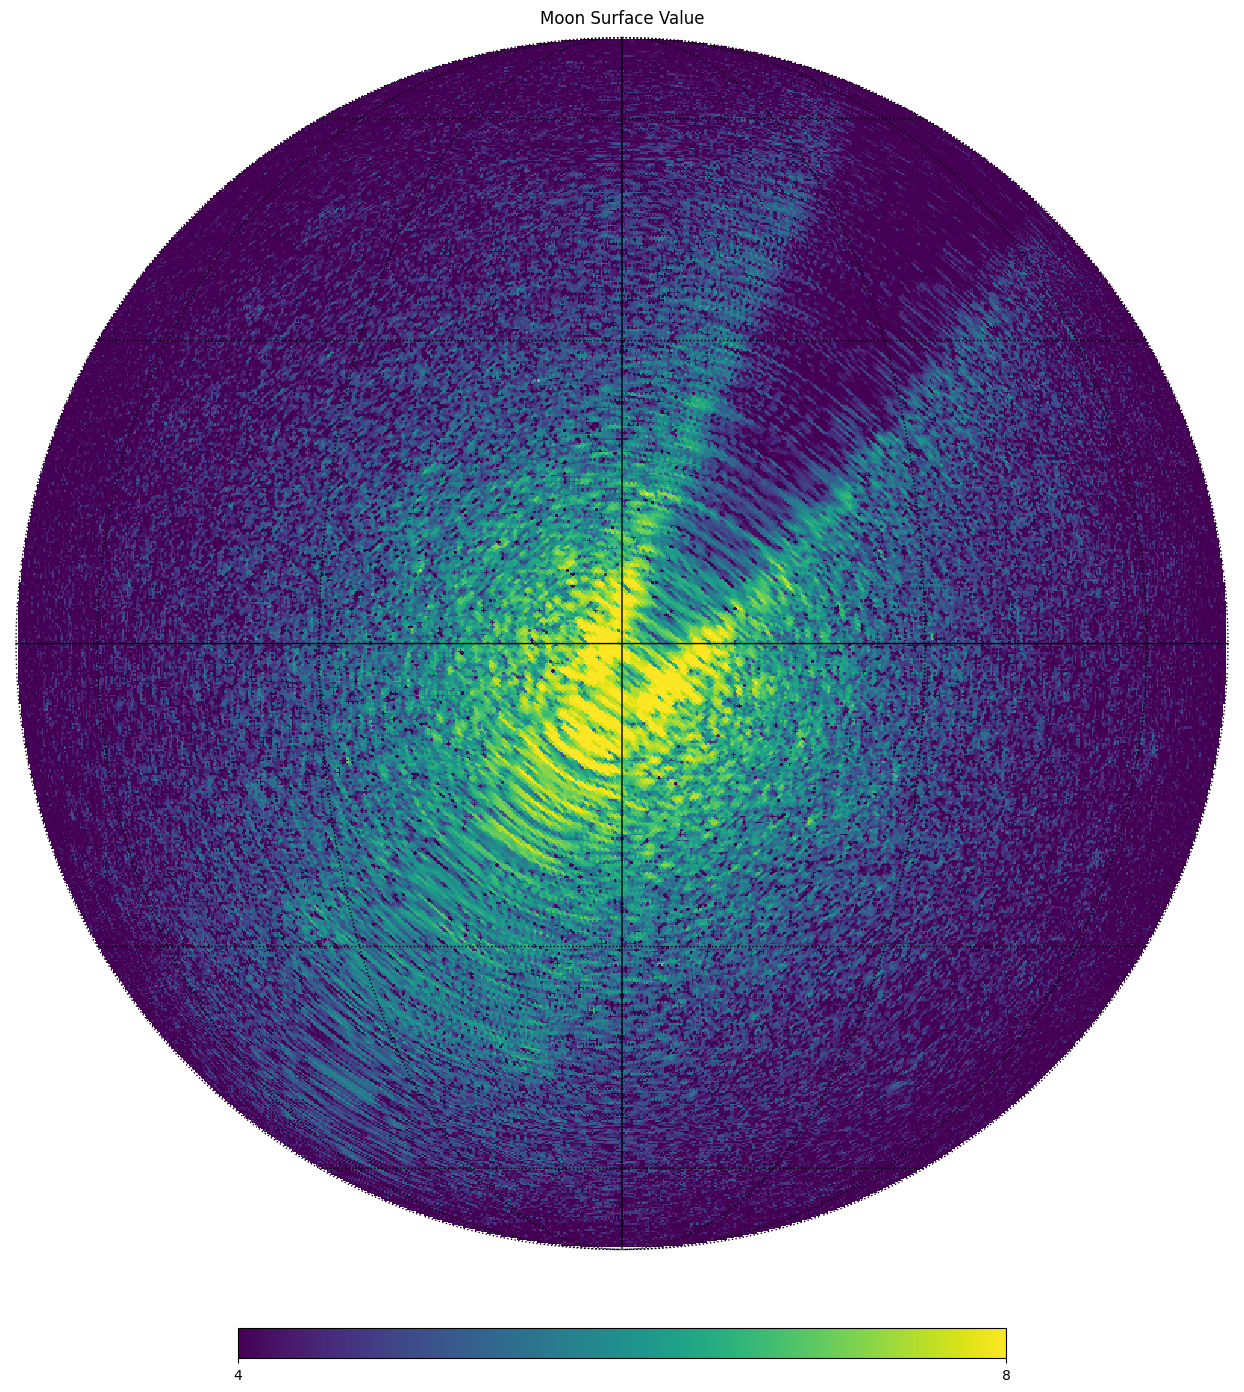

In [30]:
for rx_filename, rx_info in rx_info_map.items():
    desc = rx_info["core:description"]

    print("Considering", rx_filename, desc)

    # Common criteria
    #if not 'chan0' in rx_filename: continue
    #if not 'chan1' in rx_filename: continue
    if 'cw-' in desc: continue  # Common
    if 'pulsed' in desc: continue  # Common
    if not 'zadoff-chu' in desc: continue # Common
    #if not 'bpsk' in desc: continue
    
    if "2025-03-11" in DATA_PREFIX:  # Criteria for the 03_11 dataset
        if not (('50000-' in desc) or ('200000-' in desc)): continue  # Long tx sequence
            
    if "2025-06-21" in DATA_PREFIX:  # Criteria for the 06_21 dataset 
        #if not '30sec' in desc: continue
        if not '60sec' in desc: continue
        #if not (('60sec' in desc) or ('30sec' in desc)): continue   
        
    if "2025-09" in DATA_PREFIX:  # Criteria for the 09 datasets
        if not '30sec' in desc: continue  # No 60 sec data available :(
           
#    if not (rx_filename in SPECIAL_LIST):
#        continue
    
#if 1:
##    rx_filename = "stockert_eme_2025_03_11_19_36_21_1297.500MHz_1.00Msps_ci16_le.chan0.sigmf-meta"
##    rx_filename = "stockert_eme_2025_06_21_08_48_35_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta"
##    rx_filename = "dwingeloo_eme_2025_06_21_08_48_35_1299.500MHz_0.25Msps_ci16_le.sigmf-meta"
##    rx_filename = "stockert_eme_2025_06_21_09_46_51_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta"
#    rx_filename = "dwingeloo_eme_2025_06_21_09_46_51_1299.500MHz_0.25Msps_ci16_le.sigmf-meta"
    
    print("Processing ", rx_filename)
    rx_samples, tx_samples, sample_rate, frequency, rx_start_astrotime = loadRxTxFiles(DATA_PREFIX + rx_filename)
    
    rx_duration = len(rx_samples) / sample_rate
    tx_duration = len(tx_samples) / sample_rate
    
    if rx_duration < 20 * au.s:
        print(f"SKIPPING DUE TO SHORT RX DURATION {rx_duration=} {tx_duration=}")
        continue

    if "stockert" in rx_filename:
        RX_OBSERVER = "STOCKERT"
    if "dwingeloo" in rx_filename:
        RX_OBSERVER = "DWINGELOO"

    rx_start_time_s = csp.str2et(rx_start_astrotime.utc.value) + RX_START_OFFSET.to(au.s).value
    rx_end_time_s = rx_start_time_s + rx_duration.to(au.s).value
    
    tx_start_time_s = rx_start_time_s + TX_START_OFFSET.to(au.s).value
    tx_end_time_s = tx_start_time_s + tx_duration.to(au.s).value

    lt_tx_start, dlt_tx_start = moonLightTimeAndDeltaLightTime_spice_FWD(tx_start_time_s)
    lt_tx_end,   dlt_tx_end   = moonLightTimeAndDeltaLightTime_spice_FWD(tx_end_time_s)

    # Resample the tx samples
    # TODO: Should we resample for each moon point?
    # Note: We use the 'times0' timeframe due to poor floating point precision at high values (like rx_start_time_s).
    rx_sample_times0 = np.arange(len(rx_samples)) / sample_rate.to(au.Hz).value
    adjusted_tx_sample_times0 = np.linspace(TX_START_OFFSET.to(au.s).value + lt_tx_start, (TX_START_OFFSET + tx_duration).to(au.s).value + lt_tx_end, len(tx_samples), endpoint=False) # Stretch and offset
    
    # Complex/imaginary/phase/angle interpolation: the TX signal magnitude is 1, so we interpolate phase.
    # - This is slower, due to the angle() and exp() calls
    # - But it also allows us to use kind='linear', and generate a pure(r) signal!
    tx_phase_interp = scipy.interpolate.interp1d(adjusted_tx_sample_times0, np.angle(tx_samples), kind='linear', fill_value=np.nan, bounds_error=False)
    tx_samples_resampled = np.exp(1j * tx_phase_interp(rx_sample_times0))  # Reconstruct the complex signal
    np.nan_to_num(tx_samples_resampled, copy=False)  # Replace nans with zeros in place

    # Compensate for the time-varying carrier frequency doppler shift in the rx timeframe.
    lt_rx_start, dlt_rx_start = moonLightTimeAndDeltaLightTime_spice_BCK(rx_start_time_s)
    lt_rx_end, dlt_rx_end = moonLightTimeAndDeltaLightTime_spice_BCK(rx_end_time_s)
    doppler_start = -dlt_rx_start * frequency
    doppler_end = -dlt_rx_end * frequency
    doppler_rate = (doppler_end - doppler_start) / rx_duration
    # We choose to compensate *tx_samples_resampled* (could also apply the inverse compensation to rx_samples).
    t_s = np.arange(len(rx_samples)) / sample_rate
    phi_Hz = -(doppler_start + doppler_rate * t_s / 2)  # NOTE: NEGATIVE SHIFT for tx_samples_resampled
    tx_samples_resampled_compensated = tx_samples_resampled * np.exp(-1j * 2 * np.pi * (phi_Hz * t_s).value).T  

    # TODO: how many delay pixels wide could delay_start and delay_end be???
    #min_delay = min(lt_rx_start, lt_rx_end) * au.s
    #cor_lags, cor_i_start, cor_i_end = calculateDelayWindowIndices(sample_rate, TX_START + min_delay, len(rx_samples), len(tx_samples_resampled_compensated))
    # When tx has been resampled the correlation peak is expected at 0
    cor_lags, cor_i_start, cor_i_end = calculateDelayWindowIndices(sample_rate, 0, len(rx_samples), len(tx_samples_resampled_compensated))

    # Calculate the range of doppler shifts by sampling around the terminator.
    # Use Dwingeloo telescope as the light source (tx), UMBRAL for the edge of any illumination!
    # To do so, we have to add the tx telescope radius (20m) to observatories.tf ir ock00011.tpc, in a valid '/begindata' block:
    #  BODY399999_RADII                    = (  0.02   0.02   0.02  )
    # NOTE: Original comment said to add to observatories.tf, but I had to add to pck00011.tpc to get things working?
    # And of course... I'm not sure that this is 100% legit, but testing seems to indicate it is.
    NTERMINATOR = 1000
    target_epoch, observer_pos, v_term = csp.edterm("UMBRAL", "DWINGELOO", "MOON", rx_start_time_s, "MOON_ME", AB_COR, RX_OBSERVER, NTERMINATOR)
    lt_term, dlt_term = moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_start_time_s, v_term)

    # 3000 is roughly the delay depth / sample_rate, yielding a roughly square doppler/delay image.
    dlt_shifts = np.linspace(dlt_term.min(), dlt_term.max(), 3000)  
    # Center the frequency shifts at the doppler_start frequency, which has already been compensated for.
    f_shifts = -dlt_shifts * frequency.to(au.Hz).value - doppler_start.to(au.Hz).value

    # Calculate the doppler/delay image
    A = correlateSignalCUDA(tx_samples_resampled_compensated, rx_samples, cor_i_start, cor_i_end, f_shifts)
   
#    # Cache 
    # TODO: Also would need to cache dlt_shifts and cor_lags...
#    os.makedirs(f"results/A", exist_ok=True)
#    np.save(open(f"results/A/{rx_filename}_A.npy", 'wb'), A)

#    # Load the doppler/delay image from cache
#    A = np.load(open(f"results/A/{rx_filename}_A.npy", 'rb'))
#    sample_rate = rx_info['core:sample_rate'] / au.s
#    rx_start_astrotime = at.Time(rx_info['dt:datetime'])
  
    log_A = np.log(A)

    if 1: # Debug doppler/delay image
        os.makedirs(f"results/TEST", exist_ok=True)
        pl.imsave(f"results/TEST/{rx_filename}_log_A.png", log_A.T, vmax=log_A.max() * 0.8, vmin=log_A.max() * 0.4) 

    # These are the labeled values for each row/column of the doppler/delay image.
    dlt_values = dlt_shifts
    delay_values = cor_lags[cor_i_start:cor_i_end]

    NSIDE = 200
    NPIX = hp.nside2npix(NSIDE)
    v = np.array(hp.pix2vec(NSIDE, np.arange(NPIX))).T
    
    # Roughly filter out the far hemisphere.
    v_near = v[:, 0] > 0
    v = v[v_near, :]

    # Snapshot of all the points on the moon surface: all corrections have been done back to rx_start_astrotime
    lt, dlt = moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_start_time_s, v)
    
    ddlt = dlt_values[1] - dlt_values[0]
    ddelay = (delay_values[1] - delay_values[0]).to('s').value
    doppler_index = np.rint((dlt.max() - dlt) / ddlt).astype('i')
    delay_index = np.clip(np.rint((lt - lt.min()) / ddelay).astype('i'), min=0, max=log_A.shape[1] - 1)
    val_surface = np.zeros(NPIX, dtype=np.float32)
    val_surface[v_near] = log_A[doppler_index, delay_index]  # TODO: averaging? Would need to push points from the DD image into the healpix array

    if 1: # Debug image with predicted doppler/delay points superimposed on the doppler/delay image.
        log_A[doppler_index, delay_index] = 10
        os.makedirs(f"results/TEST", exist_ok=True)
        pl.imsave(f"results/TEST/{rx_filename}_log_A_dd.png", log_A.T, vmax=log_A.max() * 0.8, vmin=log_A.max() * 0.4) 
        log_A[:, :] = 0 # HACK
        log_A[doppler_index, delay_index] = 10
        pl.imsave(f"results/TEST/{rx_filename}_log_A_dd_points.png", log_A.T, vmax=log_A.max() * 0.8, vmin=log_A.max() * 0.4) 

    pl.close('all')
    fig = pl.figure(figsize=(16,16))
    hp.orthview(val_surface,
                title='Moon Surface Value',
                flip='geo',  # Note: moon longitude is positive EAST
                fig=fig,
                half_sky=True,
                min=log_A.max() * 0.4,
                max=log_A.max() * 0.8,
               )
    hp.graticule()
    os.makedirs(f"results/TEST", exist_ok=True)
    pl.savefig(f"results/TEST/{rx_filename}.png")
#    break

In [17]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
lt_rx_start/2

In [ ]:
if 1: # DEBUG: look at rx / tx_resampled_compensated correlation
    %matplotlib widget
    pl.close('rx_tx_corr')
    pl.figure('rx_tx_corr')
    c = scipy.signal.correlate(rx_samples, tx_samples_resampled_compensated, mode='same')
    cor_lags = scipy.signal.correlation_lags(len(rx_samples), len(tx_samples_resampled_compensated), mode='same') / sample_rate
    #pl.gca().set_xlim(-0.002, 0.002)
    pl.plot(cor_lags, c)
    pl.grid()

In [ ]:
if 1: # DEBUG: look at the rx specgram just around the notional tx OR bounce time. We're hoping for low-altitude reflections.
    %matplotlib widget
    pl.close('rx_specgram')
    pl.figure('rx_specgram', clear=True) # For widget compatibility
    Sxx_rx, f_rx, t_rx, image_rx = pl.specgram(rx_samples, Fs=sample_rate.value, NFFT=2**6, noverlap=2**5)  # High temporal resolution 
    #Sxx_rx, f_rx, t_rx, image_rx = pl.specgram(rx_samples, Fs=sample_rate.value, NFFT=2**16, clim=[-110, -80])  # High frequency resolution
    pl.gca().axvline(TX_START_OFFSET.to(au.s).value + lt_rx_start, color="black", linestyle="--")
    pl.gca().set_xlim(TX_START_OFFSET.to(au.s).value - 0.01, TX_START_OFFSET.to(au.s).value + 0.02)  # TX time
    #pl.gca().set_xlim(TX_START_OFFSET.to(au.s).value + lt_rx_start - 0.005, TX_START_OFFSET.to(au.s).value + lt_rx_start + 0.01)  # Bounce time
    pl.show()

In [ ]:
if 1: # Look at Dwingeloo's self-correlation. There is a 0.000028 s time offset between notional TX and actual RX signals!?!
    TX_START_OFFSET = 1.0 * au.s
    rx_sample_times0 = np.arange(len(rx_samples)) / sample_rate.to(au.Hz).value
    tx_sample_times0 = np.arange(len(tx_samples)) / sample_rate.to(au.Hz).value
    adjusted_tx_sample_times0 = tx_sample_times0 + TX_START_OFFSET.to(au.s).value #+ 0.000028 # HACK -- time offset to maximize tx -> rx_dwingeloo correlation?!
    
    # Complex interpolation
    tx_samples_resampled = scipy.interpolate.interp1d(adjusted_tx_sample_times0, tx_samples, kind='linear', fill_value=np.nan, bounds_error=False)(rx_sample_times0)
    
    # Phase interpolation
    #tx_phase_interp = scipy.interpolate.interp1d(adjusted_tx_sample_times0, np.angle(tx_samples), kind='linear', fill_value=np.nan, bounds_error=False)
    #tx_samples_resampled = np.exp(1j * tx_phase_interp(rx_sample_times0))  # Reconstruct the complex signal
    
    np.nan_to_num(tx_samples_resampled, copy=False)  # Replace nans with zeros in place

    if 1:
        pl.close('tx_rx_corr')
        pl.figure('tx_rx_corr', figsize=(8, 6), clear=True) # For widget compatibility
        c = scipy.signal.correlate(rx_samples, tx_samples_resampled, mode='same')
        cor_lags = scipy.signal.correlation_lags(len(rx_samples), len(tx_samples_resampled), mode='same') / sample_rate
        pl.plot(cor_lags, c)
        pl.grid()
        pl.gca().set_xlim(-0.0001, 0.0001)
        pl.title(f"Dwingeloo TX (+{TX_START_OFFSET}) to Dwingeloo RX correlation\n{rx_filename}")
        pl.gca().set_xlabel("Time (s)")
        pl.gca().axvline(TX_START_OFFSET.to(au.s).value, color="black", linestyle=":")
        pl.gca().axvline(TX_START_OFFSET.to(au.s).value + lt_rx_start, color="black", linestyle="--")
        pl.show()
    
    if 0:
        pl.close('tx_rx_plot')
        pl.figure('tx_rx_plot', clear=True) # For widget compatibility
        pl.plot(rx_sample_times0, np.angle(rx_samples))
        pl.plot(rx_sample_times0, np.angle(tx_samples_resampled))
        #pl.plot(rx_sample_times0, np.angle(tx_samples_resampled * np.exp(-1j * tx_samples[0])))  # HACK: start at zero phase
        pl.gca().set_xlim(TX_START_OFFSET.to(au.s).value - 0.001, TX_START_OFFSET.to(au.s).value + 0.002)
        #pl.gca().axvline(TX_START_OFFSET.to(au.s).value, color="black", linestyle=":")
        #pl.gca().axvline(TX_START_OFFSET.to(au.s).value + lt_rx_start, color="black", linestyle="--")
        pl.title(f"Dwingeloo TX (+{TX_START_OFFSET}) samples to Dwingeloo RX samples")
    
    #pl.close('phase_error')
    #pl.figure('phase_error', clear=True) # For widget compatibility
    #pl.plot(np.angle(rx_samples[::100]), np.angle(tx_samples_resampled[::100] - rx_samples[::100]), ',')
    #pl.title("Phase dependent phase error? Dwingeloo RX angle vs (TX - RX) angle")

In [ ]:
break

# Appendix

In [ ]:
if 0:
    # Since the delay changes during the transmission, the signal length will stretch by the change in delay from the start to the end.
    # This is one explanation for the doppler shift -- it's just a shift of timebase!
    delay_stretch = (delay_end - delay_start) * au.s
    #delay_stretch = -1.79877e-6 # "ppm" from Thomas' email
    print(f"{delay_stretch=}")
    print(delay_stretch / rx_duration)
    print(delay_stretch / rx_duration * frequency)
    
    # Compare this with the instantaneous doppler factors:
    print(doppler_factor_start)
    print(doppler_factor_start * frequency)
    print(doppler_factor_end)
    print(doppler_factor_end * frequency)
    
    print((doppler_factor_start + doppler_factor_end) / 2.0 * frequency)

In [ ]:
if 0: # Search for best frequency/time shift using peak correlation strength, in a window around the expect return time.

    # Compute the doppler/delay for the sub-radar point at the start and end of the rx window.
    delay_start, dlt_start = moonDopplerFactorAndDelay_spice(rx_start_astrotime)
    rx_end_astrotime = rx_start_astrotime + rx_duration
    delay_end, dlt_end = moonDopplerFactorAndDelay_spice(rx_end_astrotime)
    f_shift_start = dlt_start * frequency
    f_shift_end = dlt_end * frequency
    print(f"{f_shift_start=}")
    print(f"{f_shift_end=}")
    # Simple 'bulk' doppler_rate model, linear from start to end. Generally good enough for a "look" of a few minutes.
    f_shift_rate = (f_shift_end - f_shift_start) / rx_duration
    print(f"{f_shift_rate=}")

    min_delay = min(delay_start, delay_end) * au.s
    print(f"{min_delay=}")
    cor_lags, cor_i_start, cor_i_end = calculateDelayWindowIndices(sample_rate, TX_START_OFFSET + min_delay, len(rx_samples), len(tx_samples))

    f_shifts = np.linspace(f_shift_start.to(au.Hz).value - 0.2, f_shift_start.to(au.Hz).value + 0.2, 100)
    
    # Do heavy compute in GPU memory
    cupy_tx_samples = cupy.asarray(tx_samples, dtype=cupy.complex64)
    cupy_rx_samples = cupy.asarray(rx_samples, dtype=cupy.complex64)
    # Cache computations/allocations outside the for loop.
    cupy_fft_rx_samples = cupy.fft.fft(cupy_rx_samples)
    #cupy_conj_fft_tx_samples = cupy.conj(cupy.fft.fft(cupy.pad(cupy_tx_samples, (0, len(rx_samples) - len(tx_samples)))))
    #cupy_rx_range = -1j * 2 * cupy.pi / sample_rate.value * cupy.arange(len(rx_samples))
    #cupy_rx_t_s = cupy.arange(len(rx_samples)) / sample_rate.value
    cupy_tx_samples_shifted = cupy.zeros_like(rx_samples)
    cupy_tx_range = 1j * 2 * cupy.pi / sample_rate.value * cupy.arange(len(tx_samples)) 
    
    best_peak_doppler = doppler_start
    best_peak_cor = 0.0
    for i in tqdm(range(len(f_shifts))):
        cupy_tx_samples_shifted[:len(tx_samples)] = cupy_tx_samples * cupy.exp(f_shifts[i] * cupy_tx_range)
        cupy_cor_shifted = cupy.fft.ifft(cupy_fft_rx_samples * cupy.conj(cupy.fft.fft(cupy_tx_samples_shifted)))
        cor_max = cupy.max(cupy.abs(cupy_cor_shifted[cor_i_start:cor_i_end]))
        if cor_max > best_peak_cor:
            best_peak_cor = cor_max
            best_peak_doppler = cupy_f_shifts[i]

    print(f"{best_peak_doppler=}")
    print(f"{best_peak_cor=}")
    print(f"Calculated vs search doppler delta: {doppler_start - best_peak_doppler * au.Hz}")

    doppler_start = best_peak_doppler * au.Hz

    if 1: # Debug
        phi_Hz = (-best_peak_doppler * cupy_rx_t_s) + (-doppler_rate.value * cupy_rx_t_s**2) / 2
        cupy_rx_samples_shifted = cupy_rx_samples * cupy.exp(-1j * 2 * np.pi * phi_Hz).T
        cupy_cor_shifted = cupy.fft.ifft(cupy.fft.fft(cupy_rx_samples_shifted) * cupy_conj_fft_tx_samples)
        pl.figure()
        pl.title("RX-compensated/TX correlation (delay window)")
        pl.plot(cor_lags[cor_i_start:cor_i_end], cupy.abs(cupy_cor_shifted[cor_i_start:cor_i_end]).get(), label="signal")
        #pl.gca().axvline(delay_start, linestyle="--", color="grey", label="expected based on Moon distance",)
        #pl.plot(cupy.abs(cupy_cor_shifted[cor_i_start:(cor_i_start+2000)]).get())
        #rx_samples_compensated = cupy_rx_samples_shifted.get()

In [ ]:
# Use ltime to find the precise TX time for each RX sample.

dwingeloo_id = csp.bodn2c("DWINGELOO")
stockert_id = csp.bodn2c("STOCKERT")
moon_id = csp.bodn2c("MOON")

dprint("dwingeloo_id")
dprint("stockert_id")
dprint("moon_id")

# Work backwards from the signal rx time at Stockert.
rx_time_stockert = csp.str2et(rx_start_astrotime.utc.value)
bounce_time_moon, elapsed_m_to_s = csp.ltime(rx_time_stockert, stockert_id, "<-", moon_id)
tx_time_dwingeloo, elapsed_d_to_m = csp.ltime(bounce_time_moon, moon_id, "<-", dwingeloo_id)

dprint("rx_start_astrotime")
dprint("rx_time_dwingeloo")
dprint("bounce_time_moon")
dprint("tx_time_stockert")

dprint("elapsed_d_to_m")
dprint("elapsed_m_to_s")
dprint("elapsed_d_to_m + elapsed_m_to_s")

delay_start, doppler_factor_start = moonLightTimeAndDeltaLightTime(rx_start_astrotime)
dprint("delay_start")

#p_moon, lt_m_to_s, dlt_m_to_s = csp.spkltc(moon_id, rx_time_stockert, "MOON_ME", "LT")
#for abcorr in ["NONE", "LT", "LT+S", "CN", "CN+S"]:
for abcorr in ["LT", "CN"]:
    p_moon, lt_m_to_s  = csp.spkezp(moon_id, rx_time_stockert, "ITRF93", abcorr, stockert_id)
    bounce_time_moon = rx_time_stockert - lt_m_to_s
    dprint("bounce_time_moon")
    #p_dwingeloo, lt_d_to_m  = csp.spkezp(dwingeloo_id, bounce_time_moon, "ITRF93", abcorr, moon_id)
    #print(f"{abcorr:8s} ", end='')
    #dprint("lt_m_to_s")
   # dprint("lt_d_to_m")
#p_tx_from_sr, lt_tx = csp.spkcpo_vector("STOCKERT", rx_time - lt_rx, ref_frame, "OBSERVER", ab_cor, p_moon_surf, "MOON", "MOON_ME")  # Bistatic: RX by Stockert
#v_sr_from_rx = csp.dvnorm_vector(surf_p_moon_from_rx)
#v_tx_from_sr = csp.dvnorm_vector(p_tx_from_sr)  # NOTE: Including the (1-dlt_r) factor from https://destevez.net/2025/04/analysis-of-the-camras-venus-radar-experiment/ makes only about 0.00025 Hz difference.
#c = csp.clight()